In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('C:\\Users\\Администратор\\Documents\\study\\APS\\data\\demographics.csv')
data.isna().sum()

age_at_time_of_referral           1628
gender                               0
race                              3849
marital_status_description       17129
veteran_ind                          0
housing_arrangement                  3
does_client_live_alone           19005
prior_aps_history_before_2022        0
dtype: int64

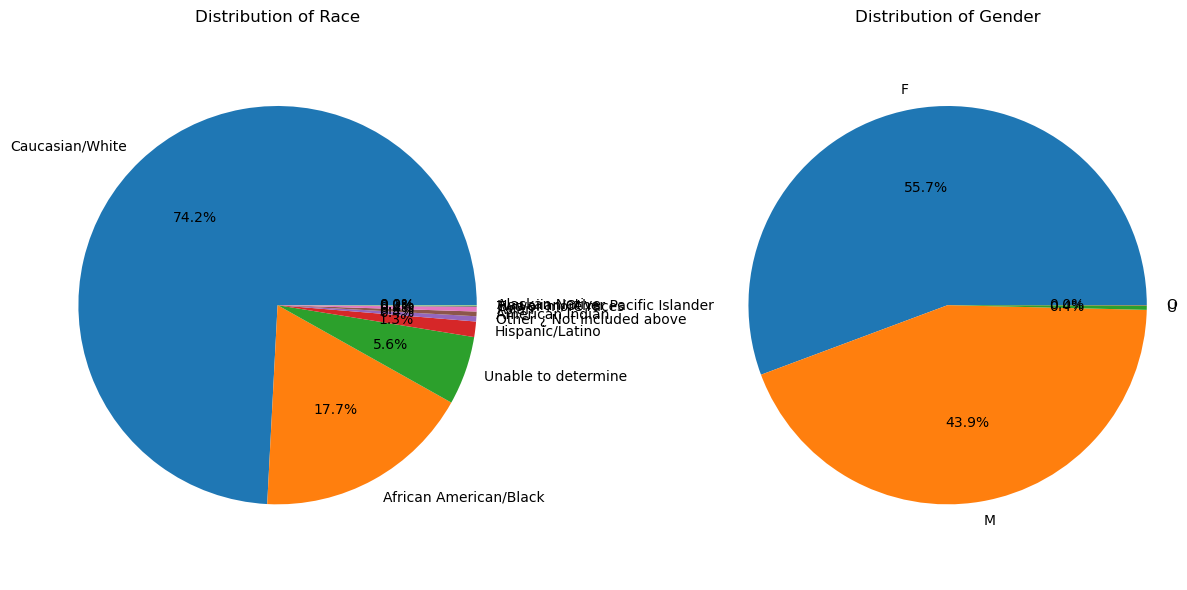

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(data['race'].value_counts(), labels=data['race'].value_counts().index, autopct='%1.1f%%')
axes[0].set_title('Distribution of Race')
axes[0].axis('equal')
axes[1].pie(data['gender'].value_counts(), labels=data['gender'].value_counts().index, autopct='%1.1f%%')
axes[1].set_title('Distribution of Gender')
axes[1].axis('equal')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

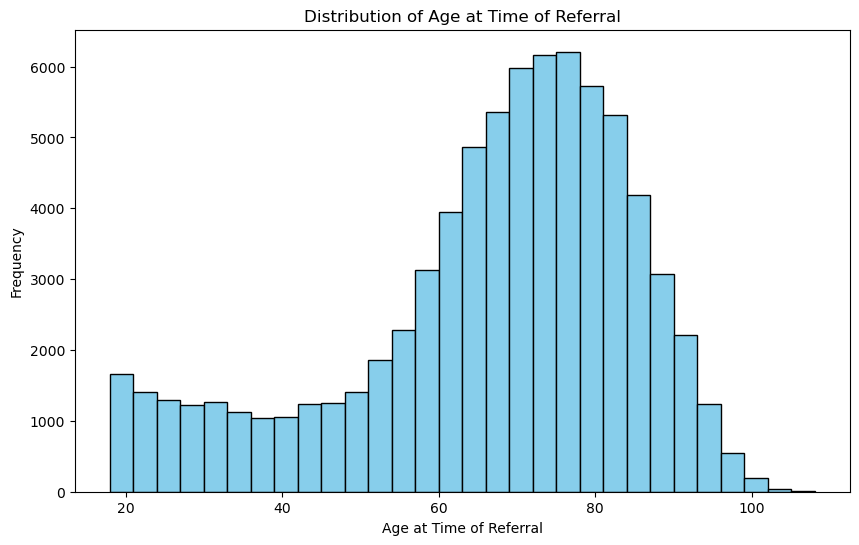

In [19]:
# distribution of age
plt.figure(figsize=(10, 6))
plt.hist(data['age_at_time_of_referral'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Age at Time of Referral')
plt.xlabel('Age at Time of Referral')
plt.ylabel('Frequency')
plt.show

QUESTIONS TO EXPLORE:
1. Those who status of living alone are missing, what are their house_arrangement?
2. Those who marital status are missing, how old are they? what are their gender?

In [4]:
data.shape

(77949, 8)

In [5]:
data['gender'].value_counts()   

gender
F    43402
M    34253
U      275
O       19
Name: count, dtype: int64

In [13]:
data[(data['marital_status_description'].isna()) & (data['gender']=="U")].shape[0]

data['marital_missing'] = data['marital_status_description'].isna()

data.groupby('gender')['marital_missing'].value_counts(dropna=False)

gender  marital_missing
F       False              33889
        True                9513
M       False              26899
        True                7354
O       False                 10
        True                   9
U       True                 253
        False                 22
Name: count, dtype: int64

In [4]:
print(data[data['does_client_live_alone'].isna()].gender.value_counts(), "\n")
print(data['housing_arrangement'].value_counts())
# print(data[data['does_client_live_alone'].isna()].veteran_ind.value_counts())

gender
F    9756
M    9036
U     203
O      10
Name: count, dtype: int64 

housing_arrangement
Own Home                          30209
Rental                            13111
Home of Another                   11446
AFC/HA                             6789
Nursing Facility/Rehab. Center     6679
Other                              4410
Assisted Living                    3054
Homeless                           1857
Shelter                             286
Jail                                105
Name: count, dtype: int64


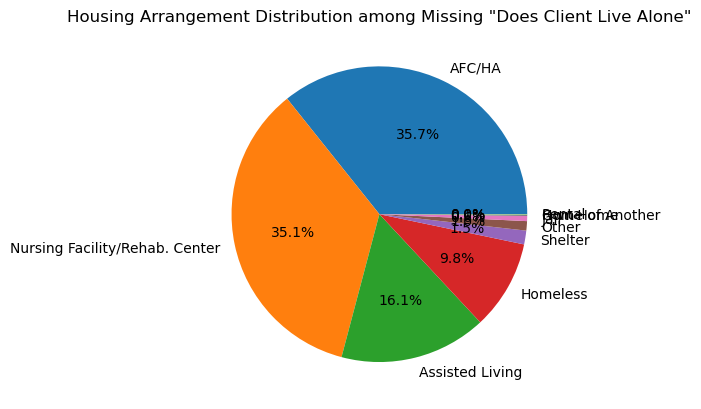

In [15]:
# Housing Arrangement Distribution among Missing 'does_client_live_alone'

plt.pie(data[data['does_client_live_alone'].isna()].housing_arrangement.value_counts(), labels=data[data['does_client_live_alone'].isna()].housing_arrangement.value_counts().index, autopct='%1.1f%%')
plt.title('Housing Arrangement Distribution among Missing "Does Client Live Alone"')
plt.show()

Adult Foster Care (AFC) and Homes for the Aged (HA)


Text(0, 0.5, 'Proportion of Missing Marital Status')

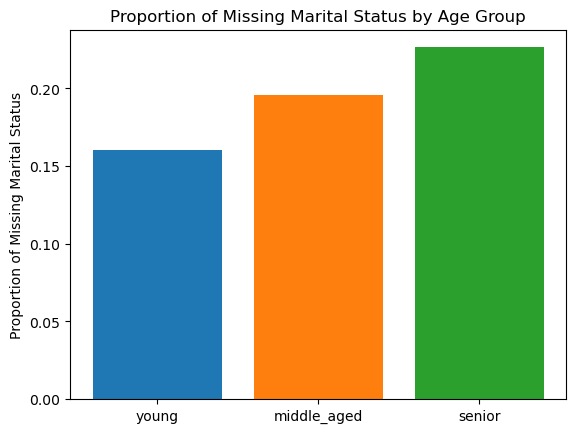

In [13]:
# marital status missing among different age groups
df_temp = data.copy()
df_temp['young'] = df_temp['age_at_time_of_referral'] < 30
df_temp['middle_aged'] = (df_temp['age_at_time_of_referral'] >= 30) & (df_temp['age_at_time_of_referral'] < 60)
df_temp['senior'] = df_temp['age_at_time_of_referral'] >= 60
age_groups = ['young', 'middle_aged', 'senior']

# visualization
for group in age_groups:
    plt.bar(group, df_temp[df_temp[group]]['marital_status_description'].isna().mean())
plt.title('Proportion of Missing Marital Status by Age Group')
plt.ylabel('Proportion of Missing Marital Status')

Missingness increased along with the age of client.

Text(0.5, 1.0, 'Housing Arrangement Distribution among Missing Marital Status in Senior Group')

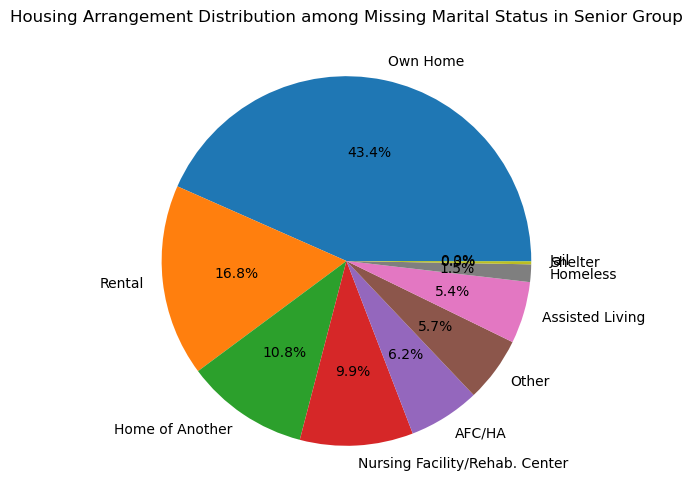

In [14]:
# housing arrangement of missingness of marital status in senior group 
plt.figure(figsize=(8, 6))
plt.pie(df_temp[df_temp['senior'] & df_temp['marital_status_description'].isna()]['housing_arrangement'].value_counts(), labels=df_temp[df_temp['senior'] & df_temp['marital_status_description'].isna()]['housing_arrangement'].value_counts().index, autopct='%1.1f%%')
plt.title('Housing Arrangement Distribution among Missing Marital Status in Senior Group')

In [6]:
print(data['marital_status_description'].value_counts(), "\n")
print(data[data['marital_status_description'].isna()].housing_arrangement.value_counts())

marital_status_description
Single-Never Married       26689
Widowed                    13288
Married-Living Together     9961
Divorced                    8731
Married-Separated           2049
Domestic Partner              95
Unknown                        7
Name: count, dtype: int64 

housing_arrangement
Own Home                          6252
Rental                            2919
Home of Another                   2404
AFC/HA                            1666
Nursing Facility/Rehab. Center    1461
Other                             1037
Assisted Living                    826
Homeless                           463
Shelter                             82
Jail                                17
Name: count, dtype: int64


In [7]:
# 1. Is the housing actually different, or just mirroring the baseline?
print("--- HOUSING PROPORTIONS ---")
print("Clients WITH Marital Status:")
print(round(data[~data['marital_status_description'].isna()]['housing_arrangement'].value_counts(normalize=True).head(4) * 100, 1))

print("\nClients MISSING Marital Status:")
print(round(data[data['marital_status_description'].isna()]['housing_arrangement'].value_counts(normalize=True).head(4) * 100, 1))

# 2. Check for Cognitive Impairment (Testing Hypothesis B)
# We will use age as a quick proxy, or you can use your specific 'client_closing_risk_confused' column
print("\n--- AGE & CONFUSION CHECK ---")
print(f"Average Age (Has Status): {data[~data['marital_status_description'].isna()]['age_at_time_of_referral'].mean():.1f}")
print(f"Average Age (Missing Status): {data[data['marital_status_description'].isna()]['age_at_time_of_referral'].mean():.1f}")

--- HOUSING PROPORTIONS ---
Clients WITH Marital Status:
housing_arrangement
Own Home                          39.4
Rental                            16.8
Home of Another                   14.9
Nursing Facility/Rehab. Center     8.6
Name: proportion, dtype: float64

Clients MISSING Marital Status:
housing_arrangement
Own Home           36.5
Rental             17.0
Home of Another    14.0
AFC/HA              9.7
Name: proportion, dtype: float64

--- AGE & CONFUSION CHECK ---
Average Age (Has Status): 65.5
Average Age (Missing Status): 67.7


QUESTIONS TO EXPLORE:

1. 

In [16]:
Female_missing = data[(data['gender']=='F') & data['does_client_live_alone'].isna()]

Male_missing = data[(data['gender']=='M') & data['does_client_live_alone'].isna()]

Unknown_missing = data[(data['gender']=='U') & data['does_client_live_alone'].isna()]

print(f"Number of missing 'does_client_live_alone' for FEMALES: {Female_missing.shape[0]}")
print(f"Number of missing 'does_client_live_alone' for MALES: {Male_missing.shape[0]}")
print(f"Number of missing 'does_client_live_alone' for UNKNOWN gender: {Unknown_missing.shape[0]}")
print(f'Other missing values: {data["does_client_live_alone"].isna().sum() - (Female_missing.shape[0] + Male_missing.shape[0] + Unknown_missing.shape[0])}')


Number of missing 'does_client_live_alone' for FEMALES: 9756
Number of missing 'does_client_live_alone' for MALES: 9036
Number of missing 'does_client_live_alone' for UNKNOWN gender: 203
Other missing values: 10


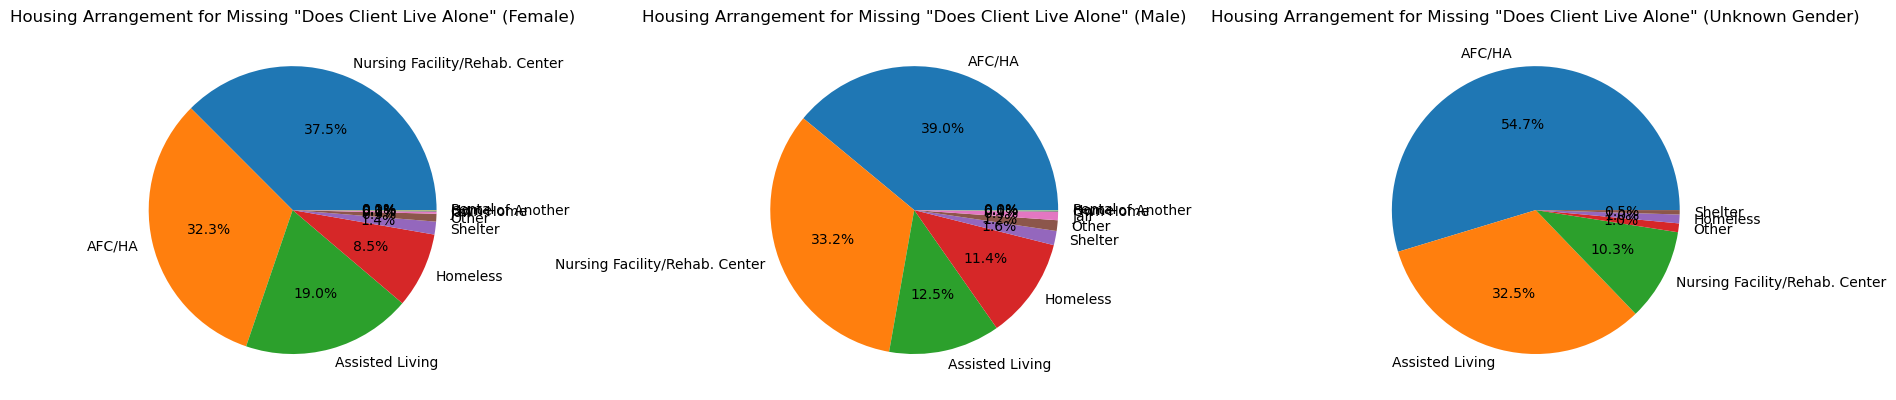

In [17]:


fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].pie(Female_missing['housing_arrangement'].value_counts(), labels=Female_missing['housing_arrangement'].value_counts().index, autopct='%1.1f%%')   
ax[0].set_title('Housing Arrangement for Missing "Does Client Live Alone" (Female)')
ax[1].pie(Male_missing['housing_arrangement'].value_counts(), labels=Male_missing['housing_arrangement'].value_counts().index, autopct='%1.1f%%')
ax[1].set_title('Housing Arrangement for Missing "Does Client Live Alone" (Male)')
ax[2].pie(Unknown_missing['housing_arrangement'].value_counts(), labels=Unknown_missing['housing_arrangement'].value_counts().index, autopct='%1.1f%%')
ax[2].set_title('Housing Arrangement for Missing "Does Client Live Alone" (Unknown Gender)')
plt.tight_layout()
plt.show()

In [1]:
Female_missing_marital = data[(data['gender']=='F') & data['marital_status_description'].isna()]
Male_missing_marital = data[(data['gender']=='M') & data['marital_status_description'].isna()]
Unknown_missing_marital = data[(data['gender']=='U') & data['marital_status_description'].isna()]

print(f"Number of missing 'marital_status_description' for FEMALES: {Female_missing_marital.shape[0]}")
print(f"Number of missing 'marital_status_description' for MALES: {Male_missing_marital.shape[0]}")
print(f"Number of missing 'marital_status_description' for UNKNOWN gender: {Unknown_missing_marital.shape[0]}")
print(f'Other missing values: {data["marital_status_description"].isna().sum() - (Female_missing_marital.shape[0] + Male_missing_marital.shape[0] + Unknown_missing_marital.shape[0])}')

NameError: name 'data' is not defined

In [12]:
print(f"Females that do not have 'does_client_live_alone' data:{Female_missing['race'].value_counts()}")
print(f"\nMales that do not have 'does_client_live_alone' data:{Male_missing['race'].value_counts()}\n")
# print(f"Unknown gender that do not have 'does_client_live_alone' data:{Unknown_missing['race'].value_counts()}")



Females that do not have 'does_client_live_alone' data:race
Caucasian/White                    6982
African American/Black             1480
Unable to determine                 543
Hispanic/Latino                      81
American Indian                      39
Asian                                37
Other ¿ Not included above           33
Two or more races                     7
Hawaiian/Other Pacific Islander       3
Alaskan Native                        2
Name: count, dtype: int64

Males that do not have 'does_client_live_alone' data:race
Caucasian/White                    6247
African American/Black             1694
Unable to determine                 442
Hispanic/Latino                      93
American Indian                      34
Other ¿ Not included above           34
Asian                                24
Two or more races                     8
Hawaiian/Other Pacific Islander       4
Alaskan Native                        4
Name: count, dtype: int64



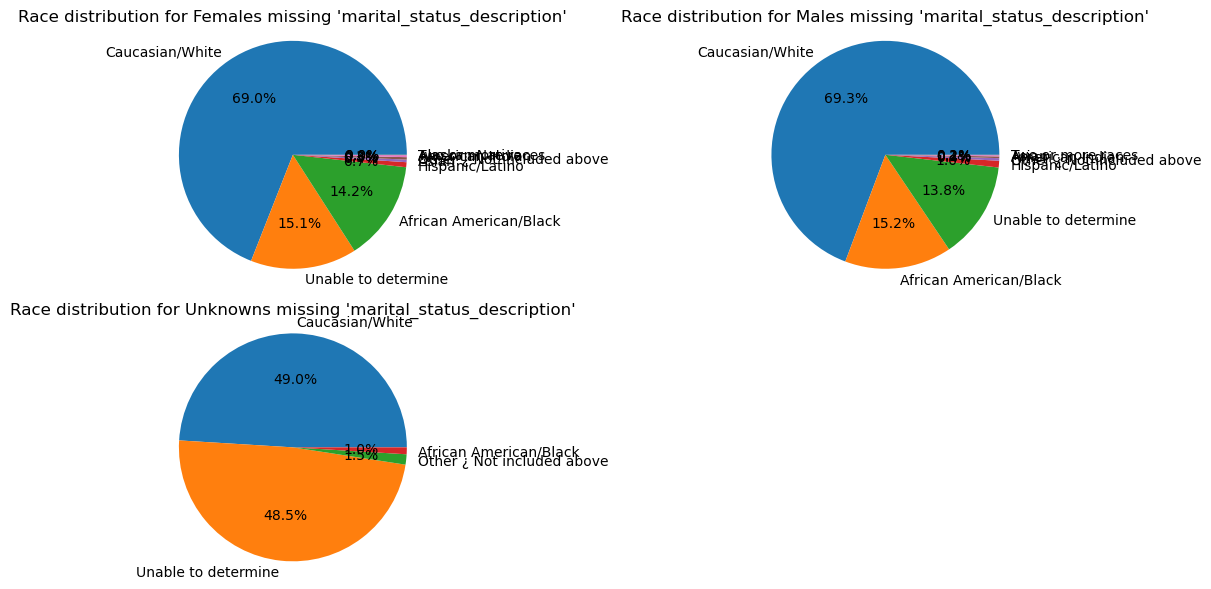

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0, 0].pie(Female_missing_marital['race'].value_counts(), labels=Female_missing_marital['race'].value_counts().index, autopct='%1.1f%%')
axes[0, 0].set_title("Race distribution for Females missing 'marital_status_description'")
axes[0, 0].axis('equal')

axes[0, 1].pie(Male_missing_marital['race'].value_counts(), labels=Male_missing_marital['race'].value_counts().index, autopct='%1.1f%%')
axes[0, 1].set_title("Race distribution for Males missing 'marital_status_description'")
axes[0, 1].axis('equal')

axes[1, 0].pie(Unknown_missing_marital['race'].value_counts(), labels=Unknown_missing_marital['race'].value_counts().index, autopct='%1.1f%%')
axes[1, 0].set_title("Race distribution for Unknowns missing 'marital_status_description'")
axes[1, 0].axis('equal')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()